## dataset : https://github.com/ageron/data/raw/main/housing.tgz

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
import tarfile
import urllib.request
import matplotlib.pyplot as plt

In [6]:
def load_housing_data():
    tarbal_path = Path("datasets/housing.tgz")
    if not tarbal_path.is_file():
        Path("./datasets").mkdir(parents=True,exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url , tarbal_path)
        with tarfile.open(tarbal_path) as housing_tarball:
            housing_tarball.extractall(path="./datasets")
    return pd.read_csv(Path("./datasets/housing/housing.csv"))

In [7]:
housing = load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [8]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [9]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [10]:
housing.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

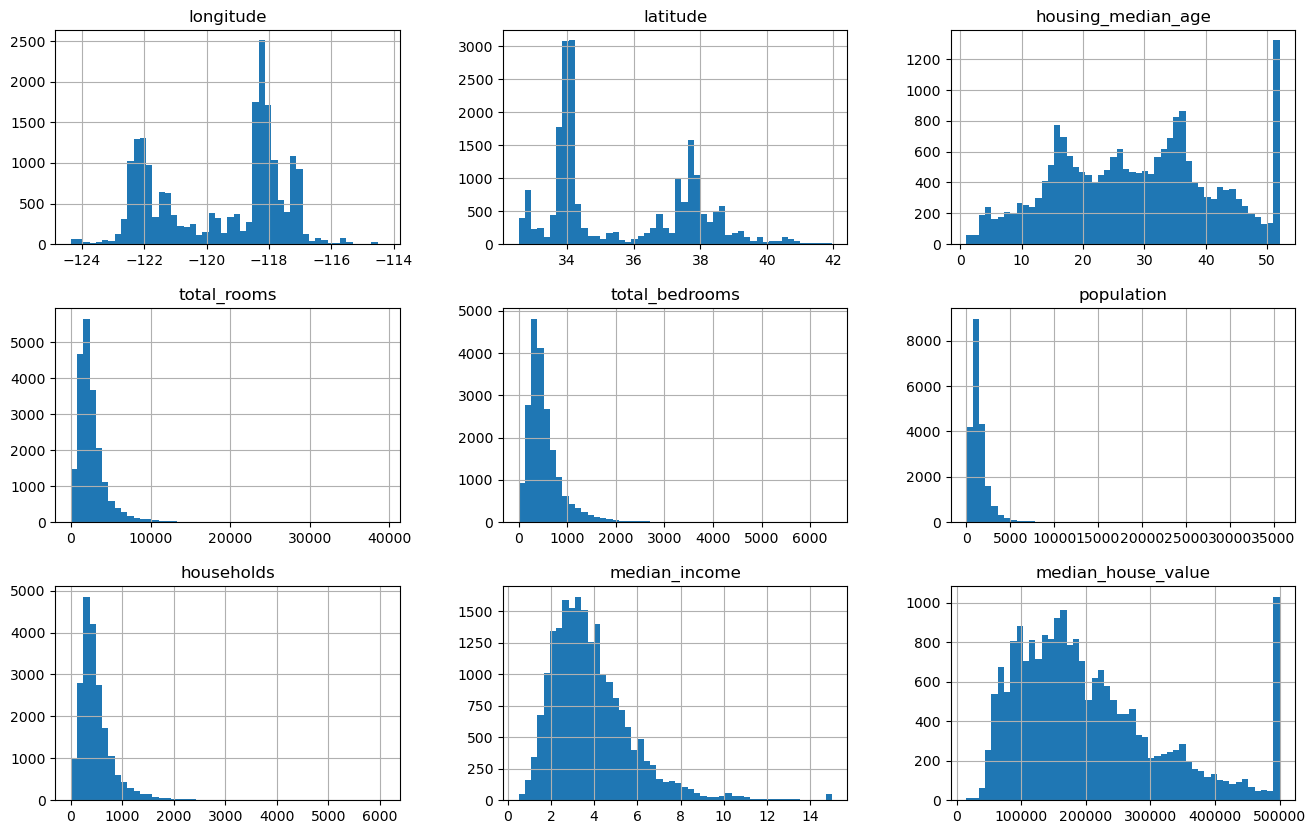

In [11]:
housing.hist(bins=50 , figsize=(16,10))
plt.show()

#### - stratified split
        - the client may have said the income category affects the most for median_house_value

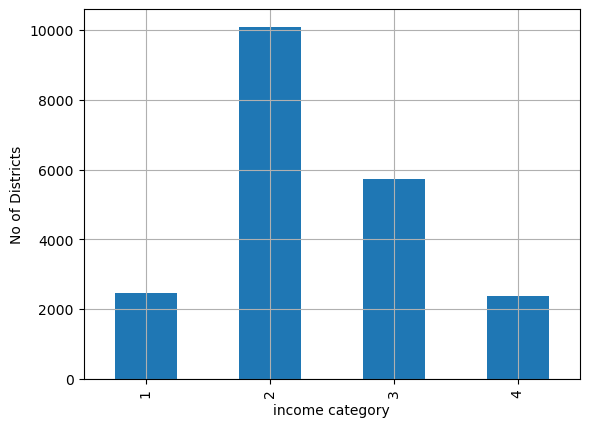

In [12]:
# creating a new column income_cat
from sklearn.model_selection import train_test_split

housing["income_cat"] = pd.cut(housing["median_income"] , bins=[0.,2.,4.,6.,np.inf],labels=[1,2,3,4])

housing["income_cat"].value_counts().sort_index().plot(kind='bar',grid=True)
plt.xlabel("income category")
plt.ylabel("No of Districts")
plt.show()

In [13]:
strat_train_set , strat_test_set = train_test_split(housing , test_size=0.2 , stratify=housing["income_cat"],random_state=42)

In [14]:
strat_train_set.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16512.000000,16512.000000,16512.000000,16512.000000,16348.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.564094,35.627174,28.637173,2612.883963,533.686934,1414.387294,496.207183,3.865925,206525.167938
std,2.005064,2.134512,12.612302,2121.451704,413.941234,1108.127797,375.874019,1.898644,115239.470577
min,-124.350000,32.540000,1.000000,2.000000,1.000000,5.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1443.000000,295.000000,785.000000,279.000000,2.555825,119200.000000
50%,-118.490000,34.250000,29.000000,2118.000000,433.000000,1165.000000,408.000000,3.529550,179500.000000
75%,-118.010000,37.710000,37.000000,3137.000000,645.000000,1720.000000,603.000000,4.750000,264500.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [15]:
strat_test_set.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,4128.000000,4128.000000,4128.000000,4128.000000,4085.000000,4128.000000,4128.000000,4128.000000,4128.000000
mean,-119.592146,35.650610,28.648740,2727.279554,554.613219,1469.834545,512.869671,3.889657,208178.412791
std,1.997477,2.141862,12.479522,2405.382718,449.607924,1224.113435,406.905272,1.904638,116022.688152
min,-124.230000,32.550000,1.000000,15.000000,4.000000,3.000000,2.000000,0.499900,14999.000000
25%,-121.820000,33.940000,18.000000,1469.000000,299.000000,793.000000,282.000000,2.608000,121400.000000
50%,-118.510000,34.270000,29.000000,2167.500000,445.000000,1171.000000,415.000000,3.558300,180800.000000
75%,-118.010000,37.720000,37.000000,3177.250000,656.000000,1749.000000,609.000000,4.722200,266425.000000
max,-114.640000,41.880000,52.000000,37937.000000,5471.000000,16122.000000,5189.000000,15.000100,500001.000000


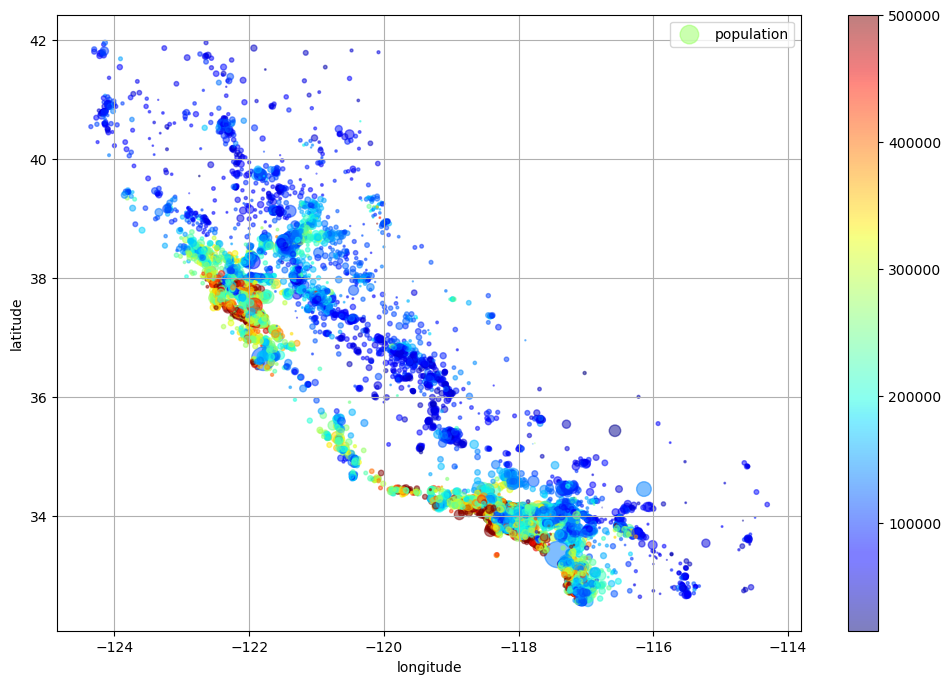

In [16]:
strat_train_set.plot(kind="scatter" , x="longitude",y="latitude", grid=True , figsize=(12,8),alpha=0.5,
                    s=strat_train_set["population"]/100 , c=strat_train_set["median_house_value"],cmap="jet",
                    label = "population" ,sharex=False,legend=True)
plt.show()

In [17]:
#adding the feature 'people_per_house'
strat_train_set["people_per_house"] = strat_train_set["population"] / strat_train_set["households"]

# adding the feature total_bedrooms to total_rooms ration
strat_train_set["bedrooms_ratio"] = strat_train_set["total_bedrooms"] / strat_train_set["total_rooms"]

# adding the feature total_rooms per house
strat_train_set["rooms_per_house"] = strat_train_set["total_rooms"] / strat_train_set["households"]

In [37]:
num_cat = strat_train_set["ocean_proximity"].unique().size
num_cat

5

In [18]:
new_housing = strat_train_set.drop(columns=["ocean_proximity"])
# new_housing.corr(housing["median_house_value"])
corr_matrix = new_housing.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687625
income_cat            0.630208
rooms_per_house       0.149741
total_rooms           0.138470
housing_median_age    0.100729
households            0.068063
total_bedrooms        0.052905
people_per_house     -0.022009
population           -0.025029
longitude            -0.039394
latitude             -0.149820
bedrooms_ratio       -0.253359
Name: median_house_value, dtype: float64

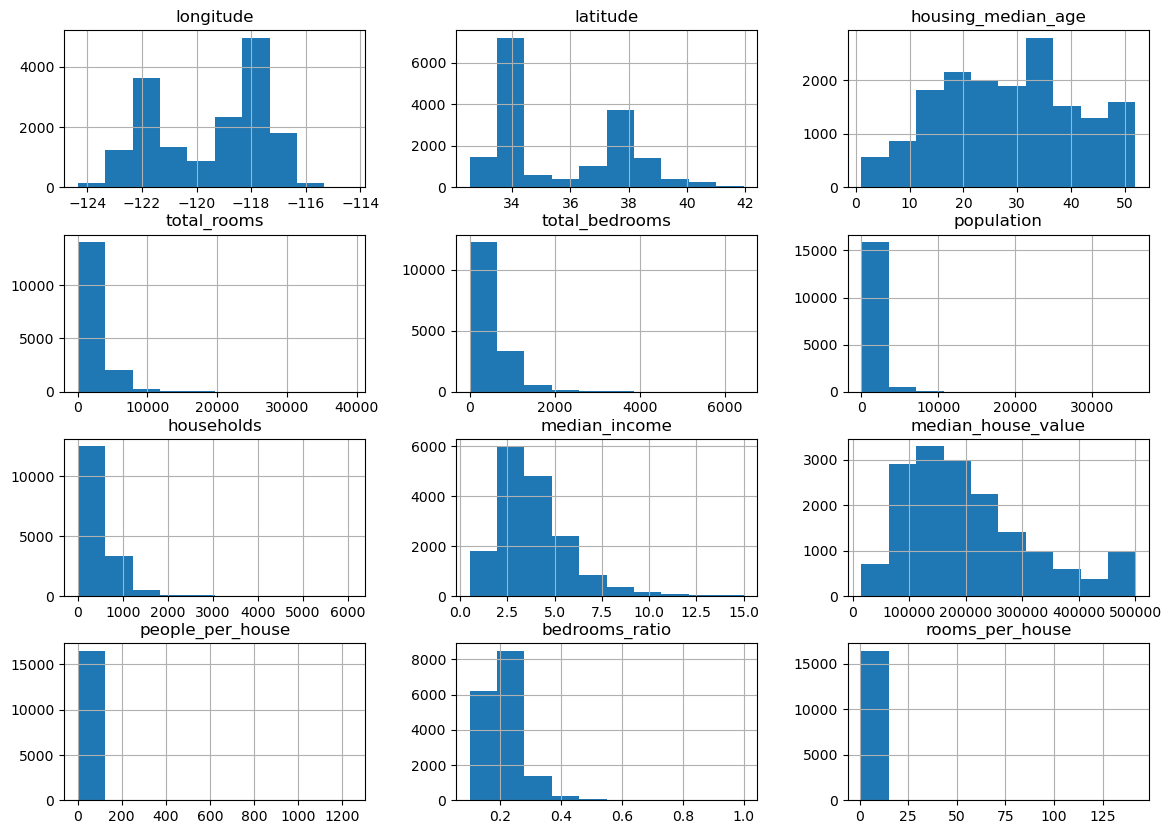

In [27]:
new_housing.hist(grid=True , figsize=(14,10))
plt.show()

#### - transform 
#### - scale
- using pipline


In [39]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector , make_column_transformer
from sklearn.preprocessing import FunctionTransformer , StandardScaler , OneHotEncoder
from sklearn.impute import SimpleImputer

In [40]:
num_pipeline = make_pipeline(SimpleImputer(strategy="median") , StandardScaler())

cat_pipeline = make_pipeline(SimpleImputer(strategy="most_frequent") , OneHotEncoder(max_categories=num_cat))

In [41]:
preprocessing = make_column_transformer(
    (num_pipeline , make_column_selector(dtype_include=np.number)),
    (cat_pipeline , make_column_selector(dtype_include=object))
    )

In [42]:
X = preprocessing.fit_transform(strat_train_set)

X

array([[ 0.93470891, -0.97316733, -2.03277324, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.63545746, -0.81856054,  0.26663879, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.95964653, -0.73891462,  0.26663879, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.37451478,  1.0835714 ,  1.37669977, ...,  1.        ,
         0.        ,  0.        ],
       [-0.94060018,  2.53593815,  0.34592886, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.22398531, -1.35734176,  0.42521893, ...,  0.        ,
         1.        ,  0.        ]])

In [43]:
X.shape

(16512, 17)

In [45]:
preprocessing.get_feature_names_out()

array(['pipeline-1__longitude', 'pipeline-1__latitude',
       'pipeline-1__housing_median_age', 'pipeline-1__total_rooms',
       'pipeline-1__total_bedrooms', 'pipeline-1__population',
       'pipeline-1__households', 'pipeline-1__median_income',
       'pipeline-1__median_house_value', 'pipeline-1__people_per_house',
       'pipeline-1__bedrooms_ratio', 'pipeline-1__rooms_per_house',
       'pipeline-2__ocean_proximity_<1H OCEAN',
       'pipeline-2__ocean_proximity_INLAND',
       'pipeline-2__ocean_proximity_NEAR BAY',
       'pipeline-2__ocean_proximity_NEAR OCEAN',
       'pipeline-2__ocean_proximity_infrequent_sklearn'], dtype=object)

In [46]:
def column_ratio(X):
    return X[:,[0]] / X[:,[1]]

def ratio_name(function_transformer , feature_names_in):
    return ["ratio"]

def ratio_pipeline():
    return make_pipeline(SimpleImputer(strategy="median") ,
                         FunctionTransformer(column_ratio , feature_names_out=ratio_name),
                         StandardScaler())



In [47]:
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator , TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel

class ClusterSimilarity(BaseEstimator , TransformerMixin):
    def __init__(self , n_clusters = 10 , gamma = 1.0 , random_state = None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self , X , y = None , sample_weights = None):
        self.kmeans_ = KMeans(n_clusters=self.n_clusters , random_state=self.random_state)
        self.kmeans_.fit(X , sample_weight=sample_weights)

        return self
    
    def transform(self , X):
        return rbf_kernel(X , self.kmeans_.cluster_centers_,gamma = self.gamma)


In [51]:
log_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                             FunctionTransformer(np.log , inverse_func=np.exp ,
                            feature_names_out="one-to-one")
                            )

cluster_sim = ClusterSimilarity(n_clusters=10 , gamma=1.0 , random_state=42)

default_num_pipeline = make_pipeline(SimpleImputer(strategy="median") , StandardScaler())



In [52]:
log_pipeline

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('functiontransformer',
                 FunctionTransformer(feature_names_out='one-to-one',
                                     func=<ufunc 'log'>,
                                     inverse_func=<ufunc 'exp'>))])

In [53]:
cluster_sim

ClusterSimilarity(random_state=42)

In [54]:
default_num_pipeline

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [55]:
cat_pipeline

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                ('onehotencoder', OneHotEncoder(max_categories=5))])

In [70]:
ratio_pipeline = ratio_pipeline()

In [75]:
from sklearn.compose import ColumnTransformer
preprocessing = ColumnTransformer([
    ("bedrooms" , ratio_pipeline , ["total_bedrooms" , "total_rooms"]),
    ("rooms_per_house" , ratio_pipeline , ["total_rooms" , "households"]),
    ("people_per_house" , ratio_pipeline , ["population" , "households"]),
    ("log" , log_pipeline , ["total_bedrooms" , "total_rooms" ,"households" , "population" , "median_income"]),
    ("geo" , cluster_sim , ["latitude" , "longitude"]),
    ("cat" , cat_pipeline , make_column_selector(dtype_include="object"))
], remainder=default_num_pipeline)

In [81]:
preprocessing

ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                             SimpleImputer(strategy='median')),
                                            ('standardscaler',
                                             StandardScaler())]),
                  transformers=[('bedrooms',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('functiontransformer',
                                                  FunctionTransformer(feature_names_out=<function ratio_name at 0x7f7c7dd0a3b0>,
                                                                      func=<function column_ratio...
                                 ['total_bedrooms', 'total_rooms', 'households',
                                  'population', 'median_income']),
                                ('geo', ClusterSimilarity(random_state=42),
                                 ['latitude', 'longitude']),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(max_categories=5))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7f7c77a3e350>)])

In [78]:
preprocessing.fit_transform(strat_train_set)

array([[-0.75298298,  0.44772849, -0.01877815, ..., -0.01877815,
        -0.83590413,  0.44772849],
       [-0.00258124, -0.41235024,  0.01878008, ...,  0.01878008,
         0.01020046, -0.41235024],
       [ 0.12868166, -0.47336498,  0.17561967, ...,  0.17561967,
         0.15820405, -0.47336498],
       ...,
       [-0.89331544, -0.01063407, -0.06356814, ..., -0.06356814,
        -0.99413396, -0.01063407],
       [-0.41964737,  0.18993525, -0.03233627, ..., -0.03233627,
        -0.4600564 ,  0.18993525],
       [-0.18608496, -0.19986234, -0.04568376, ..., -0.04568376,
        -0.19670649, -0.19986234]])

## Now you have placed all the transformation and Scaling that needs to be done the data.

## lets try and build some models

#### - Linear regression

In [83]:
strat_train_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat,people_per_house,bedrooms_ratio,rooms_per_house
3012,-117.69,33.55,3.0,1618.0,266.0,710.0,246.0,6.0743,274300.0,<1H OCEAN,4,2.886179,0.164400,6.577236
16951,-118.29,33.88,32.0,2307.0,493.0,1754.0,528.0,4.3170,232800.0,<1H OCEAN,3,3.321970,0.213697,4.369318
14747,-117.64,34.05,32.0,1129.0,251.0,1378.0,268.0,3.0057,96900.0,INLAND,2,5.141791,0.222321,4.212687
3846,-117.22,32.81,24.0,730.0,196.0,335.0,203.0,3.5078,362500.0,NEAR OCEAN,2,1.650246,0.268493,3.596059
12574,-121.71,36.88,19.0,2528.0,554.0,2332.0,492.0,3.7766,177000.0,<1H OCEAN,2,4.739837,0.219146,5.138211


In [87]:
X_train = strat_train_set.drop(columns=["ocean_proximity"] ,axis=1)
X_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,income_cat,people_per_house,bedrooms_ratio,rooms_per_house
3012,-117.69,33.55,3.0,1618.0,266.0,710.0,246.0,6.0743,274300.0,4,2.886179,0.164400,6.577236
16951,-118.29,33.88,32.0,2307.0,493.0,1754.0,528.0,4.3170,232800.0,3,3.321970,0.213697,4.369318
14747,-117.64,34.05,32.0,1129.0,251.0,1378.0,268.0,3.0057,96900.0,2,5.141791,0.222321,4.212687
3846,-117.22,32.81,24.0,730.0,196.0,335.0,203.0,3.5078,362500.0,2,1.650246,0.268493,3.596059
12574,-121.71,36.88,19.0,2528.0,554.0,2332.0,492.0,3.7766,177000.0,2,4.739837,0.219146,5.138211


In [89]:
y_train = strat_train_set["median_house_value"].copy()
y_train.head()

3012     274300.0
16951    232800.0
14747     96900.0
3846     362500.0
12574    177000.0
Name: median_house_value, dtype: float64

In [105]:
X_test = strat_test_set.drop(columns=["ocean_proximity"] ,axis=1)
y_test = strat_test_set["median_house_value"].copy()


In [109]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing , LinearRegression())

lin_reg.fit(X_train , y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7f7...
                                                   'population',
                                                   'median_income']),
                                                 ('geo',
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(max_categories=5))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7f7c77a3e350>)])),
                ('linearregression', LinearRegression())])

In [110]:
lin = lin_reg.fit(X_test , y_test)

In [111]:
from sklearn.metrics import root_mean_squared_error

lin_pred = lin.predict(X_test)

lin_rmse = root_mean_squared_error(y_test , lin_pred)

lin_rmse

5.823805759611657e-11

In [113]:
y_test.head()

2999     327500.0
4029     266700.0
19192    156900.0
13195    500001.0
11217    137500.0
Name: median_house_value, dtype: float64

In [115]:
lin_pred[0:5]

array([327500., 266700., 156900., 500001., 137500.])

#### - Decision Tree Regressor


In [134]:
processed=preprocessing.fit(X_train)

In [140]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing , DecisionTreeRegressor(random_state=42))

tree_reg.fit(X_train , y_train)
# tree_reg.fit(X_test , y_test)

d_tree_pred = tree_reg.predict(X_train)

tree_rmse = root_mean_squared_error(y_train , d_tree_pred)

tree_rmse

0.0

In [141]:
from sklearn.model_selection import cross_val_score


tree_rmse = -cross_val_score(tree_reg , X_test , y_test , scoring="neg_root_mean_squared_error" , cv=100)

In [142]:
pd.Series(tree_rmse).describe()

count     100.000000
mean      349.035387
std       315.245756
min       118.522652
25%       198.008196
50%       287.266840
75%       378.177185
max      2739.035797
dtype: float64

In [125]:
tree_rmse

array([ 235.02786056,  222.53945611,  201.77781274,  439.69686528,
        301.18812346,  191.48542155,  421.16618143,  627.73212364,
        288.26244656,  380.47589248,  320.71349029,  158.11388301,
        192.72482233,  291.54759474,  118.52265204,  181.26539343,
        327.32683535,  291.13897843,  445.07891221,  295.60269346,
        359.231985  ,  322.56413168,  382.65986389,  584.31889532,
        340.16802571,  248.80667576,  133.63062096,  174.57431219,
        458.52361165,  281.1127714 ,  377.41094895,  142.28106845,
        198.16228875,  346.0579396 ,  259.45533945,  247.42577108,
        148.1594395 ,  286.27123417,  214.70342563,  227.39242967,
        210.11030785,  334.2264458 ,  153.81331732,  214.70342563,
        174.60757394,  175.99889135,  299.18588724,  370.23394055,
        261.32868753,  313.12741893,  324.976547  ,  415.25778065,
        406.05178091,  159.26661188,  270.95135015,  150.60852177,
        284.13325627,  135.2504452 , 1459.45195193,  189.99358